# SWE plot for Canada and transboundary river basins

In this Notebook, the geospatial fabric for the "Canada and transboundary river basin" is extracted from the `MERIT-Hydro-Basins` dataset.

1️⃣ Monthly SWE Climatology Plot (Median ± IQR)

What it shows:

Median SWE across all stations for each month (solid lines)

Interquartile range (25th–75th percentile) as shaded areas

Black = observations, blue = model

How to interpret:

Timing: Compare peaks and troughs. If the model peak occurs earlier or later than observed, it may misrepresent snow accumulation or melt timing.

Magnitude: If the model median is consistently above/below observations, it may overestimate or underestimate SWE.

Spread: Wider IQR in observations than model could indicate more variability across stations than the model captures.

✅ Look for:

Does the model capture the seasonal cycle correctly?

Does the model SWE magnitude match observations?

2️⃣ Monthly HEXBIN Plots

What it shows:

Scatter of observed vs modeled SWE for each month.

Hexagonal bins show data density; red dashed line = 1:1 line.

How to interpret:

Points close to the 1:1 line → model matches observation well.

Points above the line → model overestimates SWE.

Points below the line → model underestimates SWE.

Shape of distribution: elongated along the line = model captures variability; compressed or skewed = model fails at extremes.

✅ Look for:

Seasonal bias (e.g., winter months vs spring melt)

Outliers (stations poorly simulated)

3️⃣ SWE Anomaly Comparison Plot

What it shows:

Deviations from monthly climatology, i.e., anomalies.

Helps assess interannual variability.

How to interpret:

Points along 1:1 line → model captures year-to-year variability well.

Systematic offsets → model may have bias in wet/dry years.

Scatter around zero → model struggles to capture extremes.

✅ Look for:

Whether the model reproduces snow-rich or snow-poor years.

Whether there is seasonal or station-dependent bias.

4️⃣ Peak SWE Magnitude Plot

What it shows:

Yearly maximum SWE for each station/year.

Observed vs modeled SWE (scatter)

How to interpret:

Close to 1:1 line → model reproduces peak SWE well.

Systematic over- or underestimation → model bias.

Spread → station-level variability not captured.

✅ Look for:

Peak underestimation → model may melt snow too early or not accumulate enough.

Overestimation → model may retain snow too long.

5️⃣ Peak SWE Timing Plot (Day-of-Year)

What it shows:

Day-of-year when SWE peaks for each station/year.

Observed vs modeled peak timing

How to interpret:

Points along 1:1 → correct timing.

Points above 1:1 → model peaks later than observed.

Points below 1:1 → model peaks earlier.

✅ Look for:

Seasonal shift in snowpack accumulation/melt.

Extreme deviations → model fails for specific stations (elevation, latitude).

🔹 Summary of Insights You Can Get

Magnitude Bias → How close the model SWE is to observed SWE in kg/m².

Timing Accuracy → Whether snow accumulation and melt occur at the correct time.

Variability Capture → Whether the model reproduces spatial variability across stations and interannual anomalies.

Extremes → Whether the model captures extreme events (peak SWE, wet/dry years).

Seasonal Cycle → Whether the model correctly reproduces winter accumulation and spring melt.

In practice:

Good agreement: Most points cluster along 1:1 line in hexbin plots, median lines match, peak magnitude and timing close to observed.

Systematic bias: Model consistently over- or underestimates SWE.

Timing mismatch: Peaks shift earlier/later than observations.

Station-dependent error: Some stations consistently deviate → may be topography or elevation effect.

Opening datasets...
Reading basin shapefile and spatially filtering stations...
Stations inside shapefile: 2897
Subsetting and aligning time...
Extracting SWE, applying thresholds and QC...
Applying station-level record-length filter...
Stations before filter: 2897 | after record-length filter: 2498

--- Single-station mode ---
Station ID: ALE-05BJ805



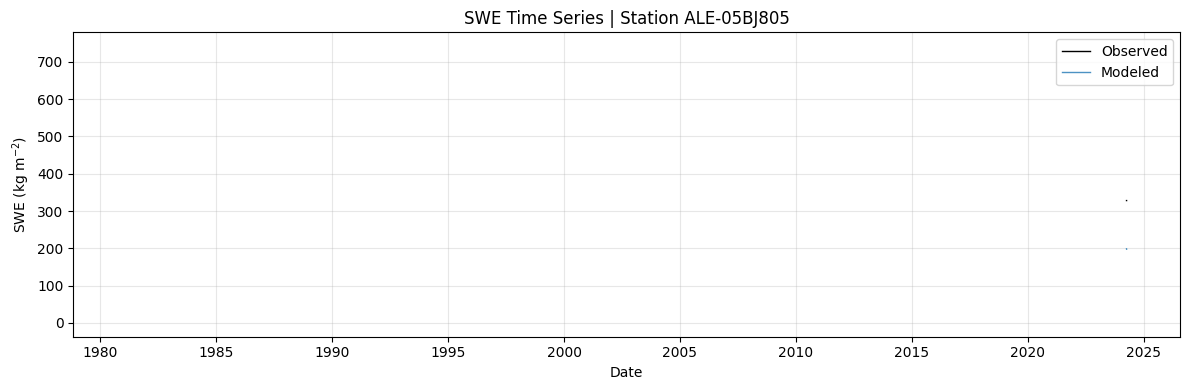

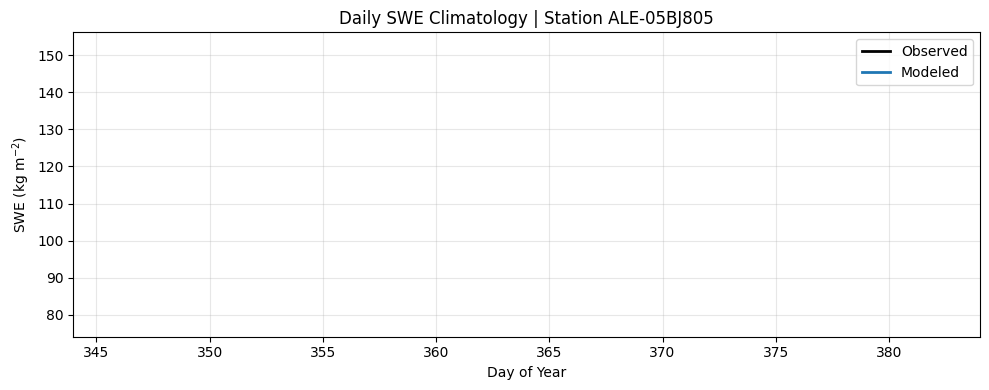

Peak SWE (obs):  nan kg m^-2
Peak SWE (mod):  nan kg m^-2
Peak DOY (obs):  nan
Peak DOY (mod):  nan


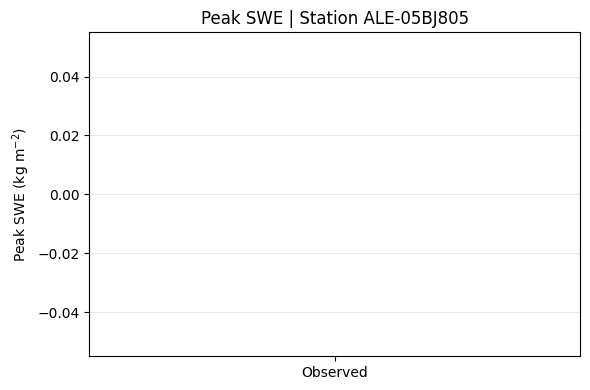

In [1]:
# ==========================================================
# FULL ROBUST SWE COMPARISON SCRIPT (Enhanced)
# - All-stations or single-station modes
# - Station-level minimum record length filter
# ==========================================================
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# ==========================================================
# USER SETTINGS
# ==========================================================
OBS_FILE   = "/scratch/zelalem/CanSWE-CanEEN_1928-2024_v7.nc"
MOD_FILE   = "/project/6102189/NAS/ModelSetup/subbasin_MESH_run/MESH_CaSRv3p2/Average_GRU_Params/mesh_lss/merged_SNO_D_GRD.nc"
#MOD_FILE2   = "/project/6102189/NAS/ModelSetup/subbasin_MESH_run/MESH_CaSRv3p2/Average_GRU_Params/mesh_lss/merged_LQWSSNO_D_GRD.nc"
SHAPEFILE  = "/home/zelalem/github-repos/community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/sorted_agg_MERIT_CanTrans_subbasins.shp"

# Temporal subset
START_DATE = "1980-01-01"
END_DATE   = "2024-12-31"

# Modes: "all" or "single"
RUN_MODE = "single"          # "all" | "single"
SINGLE_STATION_ID = "ALE-05BJ805" #None  # e.g., "123456" or 123456; only used when RUN_MODE="single"

# QC/thresholds
SWE_THRESH     = 5.0       # remove SWE below threshold in obs
MAX_SWE        = 3000.0
MIN_YEARS_DOY  = 10        # min years contributing to each DOY for climatology

# NEW: Station-level minimum record-length controls
MIN_RECORD_YEARS    = 1   # retain station only if it has >= this many "good" years
MIN_DAYS_PER_YEAR   = 1   # a "good" year has >= this many valid days

# Plotting toggles
SAVE_FIGS = True
OUTDIR    = "./figs"  # used only if SAVE_FIGS=True

# ==========================================================
# 1. READ DATA
# ==========================================================
print("Opening datasets...")
obs = xr.open_dataset(OBS_FILE)
mod = xr.open_dataset(MOD_FILE)

# Ensure time decoded correctly (safeguard if some readers altered time decoding)
obs["time"] = xr.decode_cf(obs).time
mod["time"] = xr.decode_cf(mod).time

# ==========================================================
# 2. LOAD SHAPEFILE & FILTER STATIONS INSIDE BASINS
# ==========================================================
print("Reading basin shapefile and spatially filtering stations...")
basins = gpd.read_file(SHAPEFILE)

# Build station GeoDataFrame from obs coordinates
obs_df = obs[["lat", "lon"]].to_dataframe()
obs_gdf = gpd.GeoDataFrame(
    obs_df,
    geometry=gpd.points_from_xy(obs_df["lon"], obs_df["lat"]),
    crs="EPSG:4326"
)

# Match CRS
if basins.crs != obs_gdf.crs:
    basins = basins.to_crs(obs_gdf.crs)

# Spatial join: stations within/intersecting basin polygons
obs_join = gpd.sjoin(obs_gdf, basins, how="inner", predicate="intersects")

# Subset obs by those station_ids inside basins
obs = obs.sel(station_id=obs_join.index.values)
print(f"Stations inside shapefile: {obs.station_id.size}")

# ==========================================================
# 3. MAP OBS → MODEL SUBBASINS (Rank - 1)
# ==========================================================
if "Rank" not in obs_join.columns:
    raise ValueError("Shapefile join does not contain 'Rank' column needed for subbasin mapping.")
rank_index = obs_join["Rank"].astype(int).values - 1

nearest_subbasin = xr.DataArray(
    rank_index.astype("int64"),
    dims="station_id",
    coords={"station_id": obs.station_id}
)

# ==========================================================
# 4. TIME SUBSETTING & ALIGNMENT
# ==========================================================
print("Subsetting and aligning time...")
obs = obs.sel(time=slice(START_DATE, END_DATE))
mod = mod.sel(time=slice(START_DATE, END_DATE))
obs, mod = xr.align(obs.sortby("time"), mod.sortby("time"), join="inner")

# ==========================================================
# 5. EXTRACT & CLEAN SWE (OBS + MOD) + APPLY QC
# ==========================================================
print("Extracting SWE, applying thresholds and QC...")
# Observed SWE with threshold and max clipping
obs_swe = obs["snw"].where((obs["snw"] >= SWE_THRESH) & (obs["snw"] < 1e20))
obs_swe = obs_swe.clip(max=MAX_SWE)

# Model SWE: index subbasin per-station and clip
mod_swe = mod["SNO"].isel(subbasin=nearest_subbasin)  # fancy indexing to station_id, time
mod_swe = mod_swe.transpose("station_id", "time")
mod_swe = mod_swe.clip(min=0, max=MAX_SWE)

# Apply QC flag mask for obs
if "qc_flag_snw" in obs.variables:
    qc = obs["qc_flag_snw"]
    qc_str = qc.astype(str)
    # If QC has an extra char dimension, take first
    if qc_str.ndim == 3:
        qc_str = qc_str.isel({qc_str.dims[-1]: 0})
    bad_qc = (qc_str != "") & qc_str.notnull()
    obs_swe = obs_swe.where(~bad_qc)

# Now mask model with obs availability
obs_mask = obs_swe.notnull()
mod_swe = mod_swe.where(obs_mask)

# ==========================================================
# 6. STATION-LEVEL MIN RECORD LENGTH FILTER (NEW)
# ==========================================================
print("Applying station-level record-length filter...")
# Count valid days per station per year (after QC + threshold)
valid_per_year = obs_swe.groupby("time.year").count("time")  # dims: station_id x year

# A "good year" has >= MIN_DAYS_PER_YEAR valid days
good_years_count = (valid_per_year >= MIN_DAYS_PER_YEAR).sum("year")

# Stations to keep: at least MIN_RECORD_YEARS good years
keep_station = (good_years_count >= MIN_RECORD_YEARS)

n_before = obs_swe.sizes.get("station_id", 0)
obs_swe = obs_swe.sel(station_id=keep_station)
mod_swe = mod_swe.sel(station_id=keep_station)
kept_ids = obs_swe.station_id.values
print(f"Stations before filter: {n_before} | after record-length filter: {obs_swe.station_id.size}")

if obs_swe.station_id.size == 0:
    raise RuntimeError("No stations satisfy the record-length criteria. Relax MIN_RECORD_YEARS or MIN_DAYS_PER_YEAR.")

# ==========================================================
# 7. OPTIONAL: SINGLE-STATION SELECTION (NEW)
# ==========================================================
if RUN_MODE.lower() == "single":
    if SINGLE_STATION_ID is None:
        raise ValueError("RUN_MODE='single' but SINGLE_STATION_ID is None.")
    # Make sure the dtype matches (obs_swe coordinate could be str or int)
    try:
        obs_swe_single = obs_swe.sel(station_id=SINGLE_STATION_ID)
        mod_swe_single = mod_swe.sel(station_id=SINGLE_STATION_ID)
    except Exception:
        # try coercion to str
        obs_ids_as_str = obs_swe.station_id.astype(str)
        if str(SINGLE_STATION_ID) not in set(obs_ids_as_str.values):
            raise KeyError(f"SINGLE_STATION_ID={SINGLE_STATION_ID} not found after filters.")
        obs_swe_single = obs_swe.sel(station_id=obs_ids_as_str.where(obs_ids_as_str == str(SINGLE_STATION_ID), drop=True))
        mod_swe_single = mod_swe.sel(station_id=obs_ids_as_str.where(obs_ids_as_str == str(SINGLE_STATION_ID), drop=True))

# ==========================================================
# 8. DAILY (DOY) CLIMATOLOGY
# ==========================================================
def daily_climatology(obs_da, mod_da, min_years_doy=10):
    obs_da = obs_da.assign_coords(doy=obs_da.time.dt.dayofyear)
    mod_da = mod_da.assign_coords(doy=mod_da.time.dt.dayofyear)

    obs_clim = obs_da.groupby("doy").mean("time", skipna=True)
    mod_clim = mod_da.groupby("doy").mean("time", skipna=True)

    # Count of years contributing to each DOY (1 per year at most)
    obs_doy_n = obs_da.groupby("doy").count("time")
    mod_doy_n = mod_da.groupby("doy").count("time")

    obs_clim = obs_clim.where(obs_doy_n >= min_years_doy)
    mod_clim = mod_clim.where(mod_doy_n >= min_years_doy)

    # Remove leap day
    obs_clim = obs_clim.sel(doy=slice(1, 365))
    mod_clim = mod_clim.sel(doy=slice(1, 365))
    return obs_clim, mod_clim

if RUN_MODE.lower() == "single":
    obs_doy_clim, mod_doy_clim = daily_climatology(obs_swe_single, mod_swe_single, MIN_YEARS_DOY)
else:
    obs_doy_clim, mod_doy_clim = daily_climatology(obs_swe, mod_swe, MIN_YEARS_DOY)

# ==========================================================
# 9. PEAK SWE & TIMING (ROBUST)
# ==========================================================
def peak_swe_and_timing(da, SWE_THRESH=10):
    # Keep only days with SWE >= threshold
    da = da.where(da >= SWE_THRESH)

    # Peak magnitude across time
    peak = da.max("time")

    # Stations with any valid data
    valid_station = da.notnull().any("time")
    # da_valid = da.sel(station_id=valid_station)

    if "station_id" in da.dims:
        valid_station = da.notnull().any("time")
        da_valid = da.isel(station_id=valid_station)
    else:
        # Single-station case
        if not da.notnull().any():
            return (
                da.max("time") * np.nan,
                da.max("time") * np.nan,
                da.max("time") * np.nan,
                da.max("time") * np.nan,
        )
        da_valid = da
        
    if da_valid.sizes.get("station_id", 0) == 0:
        # return all NaNs with proper dims if no valid stations
        tmpl = da.isel(time=0, drop=True) * np.nan
        return tmpl, tmpl.copy(), tmpl.copy(), tmpl.copy()

    # Indices of peak per-station
    idx = np.nanargmax(da_valid.values, axis=1)

    tmax = da_valid["time"].isel(
        time=xr.DataArray(idx, dims="station_id")
    )

    # Prepare outputs with correct dims
    doy   = xr.full_like(peak, np.nan)
    month = xr.full_like(peak, np.nan)
    day   = xr.full_like(peak, np.nan)

    doy.loc[dict(station_id=da_valid.station_id)]   = tmax.dt.dayofyear
    month.loc[dict(station_id=da_valid.station_id)] = tmax.dt.month
    day.loc[dict(station_id=da_valid.station_id)]   = tmax.dt.day

    return peak, doy, month, day

if RUN_MODE.lower() == "single":
    obs_peak, obs_doy, obs_month, obs_day = peak_swe_and_timing(obs_swe_single)
    mod_peak, mod_doy, mod_month, mod_day = peak_swe_and_timing(mod_swe_single)
else:
    obs_peak, obs_doy, obs_month, obs_day = peak_swe_and_timing(obs_swe)
    mod_peak, mod_doy, mod_month, mod_day = peak_swe_and_timing(mod_swe)

# ==========================================================
# 10. PLOTTING
# ==========================================================
def maybe_savefig(fname):
    if SAVE_FIGS:
        import os
        os.makedirs(OUTDIR, exist_ok=True)
        plt.savefig(f"{OUTDIR}/{fname}", dpi=200, bbox_inches="tight")

if RUN_MODE.lower() == "all":
    # ------------------------------
    # Spatial summary: median + IQR
    # ------------------------------
    obs_med = obs_doy_clim.median("station_id", skipna=True)
    obs_q25 = obs_doy_clim.quantile(0.25, "station_id")
    obs_q75 = obs_doy_clim.quantile(0.75, "station_id")

    mod_med = mod_doy_clim.median("station_id", skipna=True)
    mod_q25 = mod_doy_clim.quantile(0.25, "station_id")
    mod_q75 = mod_doy_clim.quantile(0.75, "station_id")

    plt.figure(figsize=(12, 5))
    plt.fill_between(obs_med["doy"], obs_q25, obs_q75, color="black", alpha=0.15, label="Obs IQR")
    plt.plot(obs_med["doy"], obs_med, "k-", lw=2, label="Observed")
    plt.fill_between(mod_med["doy"], mod_q25, mod_q75, color="tab:blue", alpha=0.25, label="Model IQR")
    plt.plot(mod_med["doy"], mod_med, color="tab:blue", lw=2, label="Modeled")
    plt.xlabel("Day of Year")
    plt.ylabel("SWE (kg m$^{-2}$)")
    plt.title(f"Daily SWE Climatology ({pd.to_datetime(START_DATE).year}–{pd.to_datetime(END_DATE).year})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    maybe_savefig("climatology_all_stations.png")
    plt.show()

    # ------------------------------
    # Station location map (after all filters)
    # ------------------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(obs["lon"].sel(station_id=kept_ids), obs["lat"].sel(station_id=kept_ids), s=8, c="red")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Observation Station Locations (kept)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    maybe_savefig("station_locations.png")
    plt.show()

    # ------------------------------
    # Peak SWE scatter
    # ------------------------------
    # Convert to numpy for masking
    obs_peak_np = obs_peak.values
    mod_peak_np = mod_peak.values
    mask = np.isfinite(obs_peak_np) & np.isfinite(mod_peak_np)

    plt.figure(figsize=(6, 6))
    plt.scatter(obs_peak_np[mask], mod_peak_np[mask], s=6, alpha=0.3)
    plt.plot([0, MAX_SWE], [0, MAX_SWE], "r--")
    plt.xlabel("Observed Peak SWE")
    plt.ylabel("Modeled Peak SWE")
    plt.title("Peak SWE Magnitude")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    maybe_savefig("peak_swe_scatter.png")
    plt.show()

    # ------------------------------
    # Peak DOY scatter
    # ------------------------------
    obs_doy_np = obs_doy.values
    mod_doy_np = mod_doy.values
    mask = np.isfinite(obs_doy_np) & np.isfinite(mod_doy_np)

    plt.figure(figsize=(6, 6))
    plt.scatter(obs_doy_np[mask], mod_doy_np[mask], s=6, alpha=0.3)
    plt.plot([0, 365], [0, 365], "r--")
    plt.xlabel("Observed Peak DOY")
    plt.ylabel("Modeled Peak DOY")
    plt.title("Peak SWE Timing")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    maybe_savefig("peak_timing_scatter.png")
    plt.show()

else:
    # ------------------------------
    # SINGLE-STATION PLOTS
    # ------------------------------
    stid = str(SINGLE_STATION_ID)
    print(f"\n--- Single-station mode ---\nStation ID: {stid}\n")

    # 1) Daily time series (entire period)
    plt.figure(figsize=(12, 4))
    plt.plot(obs_swe_single["time"], obs_swe_single, color="k", lw=1.0, label="Observed")
    plt.plot(mod_swe_single["time"], mod_swe_single, color="tab:blue", lw=1.0, label="Modeled", alpha=0.8)
    plt.xlabel("Date")
    plt.ylabel("SWE (kg m$^{-2}$)")
    plt.title(f"SWE Time Series | Station {stid}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    maybe_savefig(f"time_series_station_{stid}.png")
    plt.show()

    # 2) DOY climatology (mean over years after DOY cover filter)
    plt.figure(figsize=(10, 4))
    plt.plot(obs_doy_clim["doy"], obs_doy_clim.squeeze(), "k-", lw=2, label="Observed")
    plt.plot(mod_doy_clim["doy"], mod_doy_clim.squeeze(), "-", color="tab:blue", lw=2, label="Modeled")
    plt.xlabel("Day of Year")
    plt.ylabel("SWE (kg m$^{-2}$)")
    plt.title(f"Daily SWE Climatology | Station {stid}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    maybe_savefig(f"climatology_station_{stid}.png")
    plt.show()

    # 3) Peak stats table (print) + small bar chart
    #    (Peaks already computed: obs_peak, mod_peak are scalars here after squeeze)
    opeak = float(obs_peak.squeeze())
    mpeak = float(mod_peak.squeeze())
    odoy  = int(obs_doy.squeeze()) if np.isfinite(obs_doy.values) else np.nan
    mdoy  = int(mod_doy.squeeze()) if np.isfinite(mod_doy.values) else np.nan

    print(f"Peak SWE (obs):  {opeak:.1f} kg m^-2")
    print(f"Peak SWE (mod):  {mpeak:.1f} kg m^-2")
    print(f"Peak DOY (obs):  {odoy}")
    print(f"Peak DOY (mod):  {mdoy}")

    plt.figure(figsize=(6,4))
    plt.bar(["Observed", "Modeled"], [opeak, mpeak], color=["black", "tab:blue"], alpha=0.8)
    plt.ylabel("Peak SWE (kg m$^{-2}$)")
    plt.title(f"Peak SWE | Station {stid}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    maybe_savefig(f"peak_swe_station_{stid}.png")
    plt.show()

# ==========================================================
# END
# ==========================================================

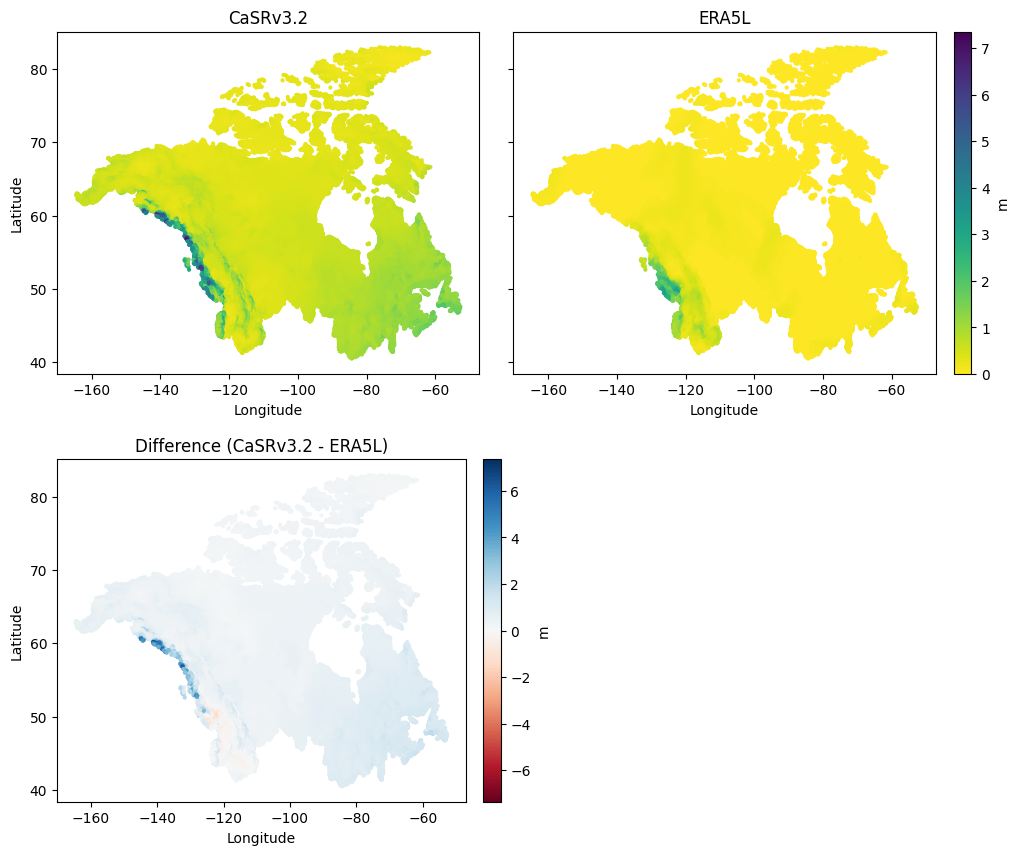

Figure saved as: mean_precip_comparison.png


In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================
# USER SETTINGS
# =========================
file1 = "/project/6102189/NAS/Forcing/MERIT_CaSRv3p2_chunk_forcing/casrv2p1_sum_mean_1980_2024.nc"
file2 = "/project/6102189/NAS/Forcing/MERIT_ERA5L_chunk_forcing/era5l_sum_mean_1980_2024.nc"

var1 = "CaSR_v3.2_A_PR0_SFC"        # variable name in file1
var2 = "p"   # variable name in file2

title1 = "CaSRv3.2"
title2 = "ERA5L"
units  = "m"   # change if needed
marker_size = 4


scale_factor = 0.001

# Output figure filename
fig_filename = "mean_precip_comparison.png"
# =========================

# -------------------------
# Open datasets
# -------------------------
ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

data1 = ds1[var1].squeeze()
data2 = ds2[var2].squeeze()

if "time" in data1.dims:
    data1 = data1.isel(time=0)
if "time" in data2.dims:
    data2 = data2.isel(time=0)

data1, data2 = xr.align(data1, data2, join="inner")

# Apply scaling
data1 = data1 * scale_factor
data2 = data2 #* scale_factor

diff = data1 - data2

lon = ds1["longitude"]
lat = ds1["latitude"]

# -------------------------
# Color scales
# -------------------------
vmin = float(np.nanmin([data1.min(), data2.min()]))
vmax = float(np.nanmax([data1.max(), data2.max()]))
diff_abs = float(np.nanmax(np.abs(diff)))

# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=(12, 10))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1],
    width_ratios=[1, 1],
    hspace=0.25,
    wspace=0.08
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax_empty = fig.add_subplot(gs[1, 1])
ax_empty.axis("off")

# ---- Mean 1 ----
sc1 = ax1.scatter(lon, lat, c=data1,
                  s=marker_size,
                  cmap="viridis_r",
                  vmin=vmin, vmax=vmax)
ax1.set_title(title1)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# ---- Mean 2 ----
sc2 = ax2.scatter(lon, lat, c=data2,
                  s=marker_size,
                  cmap="viridis_r",
                  vmin=vmin, vmax=vmax)
ax2.set_title(title2)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("")
ax2.tick_params(labelleft=False)

# ---- Shared colorbar (top plots only) ----
cbar = fig.colorbar(sc1, ax=[ax1, ax2],
                    fraction=0.035, pad=0.02)
cbar.set_label(units)

# ---- Difference ----
sc3 = ax3.scatter(lon, lat, c=diff,
                  s=marker_size,
                  cmap="RdBu",
                  vmin=-diff_abs, vmax=diff_abs)
ax3.set_title(f"Difference ({title1} - {title2})")
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")

cbar3 = fig.colorbar(sc3, ax=ax3,
                     fraction=0.046, pad=0.04)
cbar3.set_label(units)

# -------------------------
# Save the figure
# -------------------------
plt.savefig(fig_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved as: {fig_filename}")

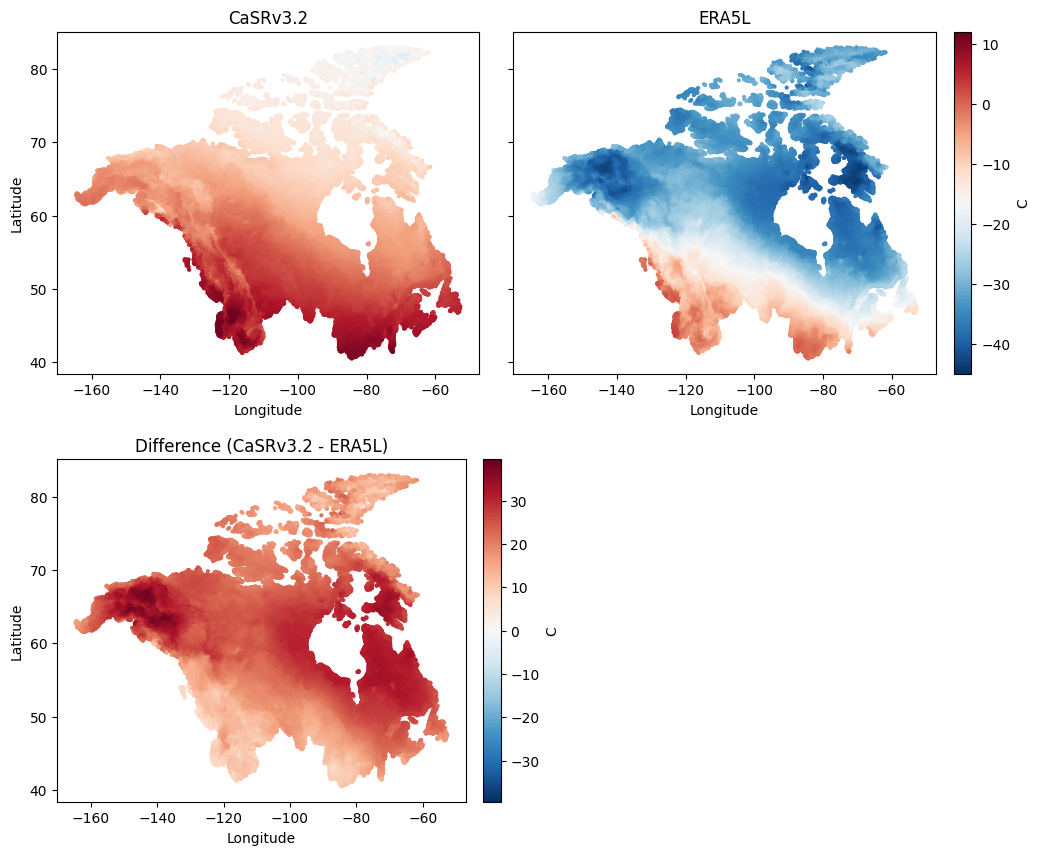

Figure saved as: mean_temp_comparison.png


In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================
# USER SETTINGS
# =========================
file1 = "/project/6102189/NAS/Forcing/MERIT_CaSRv3p2_chunk_forcing/casrv2p1_sum_mean_1980_2024.nc"
file2 = "/project/6102189/NAS/Forcing/MERIT_ERA5L_chunk_forcing/era5l_sum_mean_1980_2024.nc"

var1 = "CaSR_v3.2_P_TT_09975"        # variable name in file1
var2 = "t2m"   # variable name in file2

title1 = "CaSRv3.2"
title2 = "ERA5L"
units  = "C"   # change if needed
marker_size = 4


scale_factor = 273.16  #3600 * 385704 / 44

# Output figure filename
fig_filename = "mean_temp_comparison.png"
# =========================


# -------------------------
# Open datasets
# -------------------------
ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

data1 = ds1[var1].squeeze()
data2 = ds2[var2].squeeze()

if "time" in data1.dims:
    data1 = data1.isel(time=0)
if "time" in data2.dims:
    data2 = data2.isel(time=0)

data1, data2 = xr.align(data1, data2, join="inner")

# Apply scaling
data1 = data1 - scale_factor
data2 = data2 - scale_factor

diff = data1 - data2

lon = ds1["longitude"]
lat = ds1["latitude"]

# -------------------------
# Color scales
# -------------------------
vmin = float(np.nanmin([data1.min(), data2.min()]))
vmax = float(np.nanmax([data1.max(), data2.max()]))
diff_abs = float(np.nanmax(np.abs(diff)))

# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=(12, 10))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1],
    width_ratios=[1, 1],
    hspace=0.25,
    wspace=0.08
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax_empty = fig.add_subplot(gs[1, 1])
ax_empty.axis("off")

# ---- Mean 1 ----
sc1 = ax1.scatter(lon, lat, c=data1,
                  s=marker_size,
                  cmap="RdBu_r",
                  vmin=vmin, vmax=vmax)
ax1.set_title(title1)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# ---- Mean 2 ----
sc2 = ax2.scatter(lon, lat, c=data2,
                  s=marker_size,
                  cmap="RdBu_r",
                  vmin=vmin, vmax=vmax)
ax2.set_title(title2)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("")
ax2.tick_params(labelleft=False)

# ---- Shared colorbar (top plots only) ----
cbar = fig.colorbar(sc1, ax=[ax1, ax2],
                    fraction=0.035, pad=0.02)
cbar.set_label(units)

# ---- Difference ----
sc3 = ax3.scatter(lon, lat, c=diff,
                  s=marker_size,
                  cmap="RdBu_r",
                  vmin=-diff_abs, vmax=diff_abs)
ax3.set_title(f"Difference ({title1} - {title2})")
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")

cbar3 = fig.colorbar(sc3, ax=ax3,
                     fraction=0.046, pad=0.04)
cbar3.set_label(units)

# -------------------------
# Save the figure
# -------------------------
plt.savefig(fig_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved as: {fig_filename}")